# 第八章: 中间件
## 8.1 中间件概述
在 create_agent() 的底层运行机制中，有几个重要的组件，分别是：
1. 模型(Model) ：Agent 的“大脑”，负责理解任务与决策推理。
2. 工具(Tools) ：Agent 的“手脚”，执行模型自己做不到的外部操作。
3. 系统提示词(System Prompt) ：Agent的“角色”，告诉模型该怎么想、参考什么上下文。
4. 中间件(Middleware) ：Agent的“中枢”，在执行流程的关键节点进行拦截、控制和增强。

```python

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,
HumanInTheLoopMiddleware
agent = create_agent(
    model="gpt-5.4-mini",
    tools=[...],
    middleware=[
        SummarizationMiddleware(...),
        HumanInTheLoopMiddleware(...)
    ],
)
```

agent创建时 代码:

```python
create_agent(
  model: str | BaseChatModel,
  tools: Sequence[BaseTool | Callable[..., Any] | dict[str, Any]] | None = None,
  *,
  system_prompt: str | SystemMessage | None = None,
  middleware: Sequence[AgentMiddleware[StateT_co, ContextT]] = (),
  response_format: ResponseFormat[ResponseT] | type[ResponseT] | dict[str, Any] | None = None,
  state_schema: type[AgentState[ResponseT]] | None = None,
  context_schema: type[ContextT] | None = None,
  checkpointer: Checkpointer | None = None,
  store: BaseStore | None = None,
  interrupt_before: list[str] | None = None,
  interrupt_after: list[str] | None = None,
  debug: bool = False,
  name: str | None = None,
  cache: BaseCache[Any] | None = None,
  transformers: Sequence[TransformerFactory] | None = None
) -> CompiledStateGraph[AgentState[ResponseT], ContextT, InputAgentState, OutputAgentState[ResponseT]]
```

## 1.1 什么是中间件
Middleware(中间件)，简单说就是Agent 执行过程中的钩子函数，是 LangChain 1.x 的“王牌”工程化能力。
>钩子是框架或系统在某些关键执行点暴露的扩展接口。开发者可以“挂上”自己的逻辑，在那些点上插入、修改或替换行为，而无需改变主流程代码。就像在流水线上某个环节设置了一个“检查点”或“插入器”。

借助中间件，开发者可以高度定制和控制Agent运行的每一个环节，是处理 Agent 生命周期的标准方式。

在 LangChain 的 Agent 执行循环中，比如 “模型调用前”、“模型调用后”、“工具调用前后” 设置一些钩子
（hooks），让你在不改 Agent 主体逻辑的情况下实现策略与治理。

## 1.2 为什么需要中间件

如果没有中间件，Agent 的执行流程通常比较直接：
> 用户输入 → 拼接提示词/消息 → 调用模型 → 如有需要调用工具 → 返回结果


这种方式对于简单场景已经足够，但一旦进入真实项目，往往会遇到很多额外需求，例如：
* 想根据问题复杂度动态 切换模型 ；
* 想 限制 某些用户只能调用部分工具；
* 想在工具报错时 自动重试 或返回兜底结果；
* 想在模型调用前 插入额外的系统提示 ；
* 想记录每一步的 执行日志 ，方便排查问题；
* 想在敏感信息出现时 阻断执行 ；
* 想在正式执行工具前增加 人工审批 。

这些需求有一个共同特点：它们不是 Agent 的核心业务逻辑，但又会影响 Agent 的执行过程。如果把这些逻辑全部直接写进主流程，会带来几个问题：

1. 主流程会迅速变乱Agent 本身只需要关心“理解用户需求、决定是否调用工具、生成结果”，但一旦把日志、鉴权、重试、风控、审计都塞进去，主逻辑就会变得臃肿。
2. 很多逻辑是横切需求，难以复用例如日志、重试、风控、权限控制，通常不是某一个 Agent 独有的，而是多个 Agent 都需要。如果直接
写死在每个 Agent 里，会产生大量重复代码。
3. 流程控制粒度不够细有些逻辑必须发生在“模型调用前”，有些要发生在“工具调用后”，如果没有统一的执行拦截点，开发者只能手动改主流程，既麻烦又容易出错。
4. 后期维护成本高当你需要增加一个新规则，例如“所有外部工具调用前都先做审计”，如果系统没有中间件机制，往往需
要修改很多处代码。

总结：

中间件的价值就在于把这些与业务无关、但与执行过程强相关的横切逻辑，从 Agent 主流程中分离出来。让Agent 主体代码 聚焦业务 ，而借助中间件，实现“ 拦截流程、修改流程、增强流程 ”。

简言之，LangChain 1.x 的中间件能实现如下功能：

✅ 日志与分析 - 追踪行为、调试、性能监控

✅ 转换 - 修改提示词、工具选择、输出格式

✅ 容错 - 重试、降级、早期终止

✅ 安全 - 限流、守护规则、PII 检测

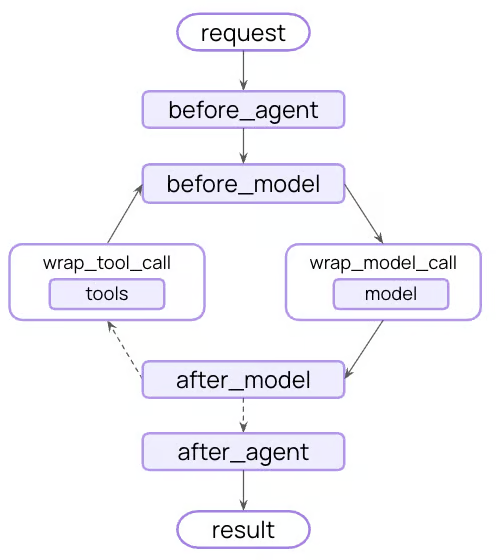

## 1.3 中间件的分类

根据LangChain是否已经定义了来分类：
* 自定义中间件：允许开发者自定义，从而实现更加灵活的Agent行为管理
* 内置中间件：LangChain实现并提供的

    1. 模型供应商定制的中间件 ：依赖于特定模型服务的实现（不是本课的重点）
    2. 和模型供应商无关的中间件 : LangChain提供的与供应商无关的中间件如下：

官方文档预定义的中间件介绍: https://docs.langchain.com/oss/python/langchain/middleware/built-in#tool-error

## 1.4 和模型供应商无关的内置中间件分类
LangChain提供的和模型供应商无关的内置中间件按用途分为七个类别

下面按“中间件管的是 Agent 运行中的哪件事”来分。以本项目安装的 langchain 1.4.2 为准，`langchain.agents.middleware` 中共有 16 个与供应商无关的内置中间件：

| 类别 | 解决的问题 | 包含的中间件 |
|---|---|---|
| 1.4.1 上下文管理 | 对话越来越长，超出模型的上下文窗口 | ⭐ `SummarizationMiddleware`、`ContextEditingMiddleware` |
| 1.4.2 人工审批 | 执行有风险的工具前，先让人确认 | ⭐ `HumanInTheLoopMiddleware` |
| 1.4.3 隐私保护 | 用户的敏感信息不能原样发给模型，也不能出现在回复里 | `PIIMiddleware` |
| 1.4.4 调用限制 | 防止 Agent 陷入死循环、费用失控 | ⭐ `ModelCallLimitMiddleware`、⭐ `ToolCallLimitMiddleware` |
| 1.4.5 容错 | 模型或工具出错时，重试、换模型，或把错误交给模型处理 | ⭐ `ModelRetryMiddleware`、⭐ `ModelFallbackMiddleware`、⭐ `ToolRetryMiddleware`、`ToolErrorMiddleware` |
| 1.4.6 工具管理 | 工具太多时决定给模型看哪些；测试时不真正执行工具 | `LLMToolSelectorMiddleware`、`ProviderToolSearchMiddleware`、`LLMToolEmulator` |
| 1.4.7 能力扩展 | 直接给 Agent 添加新工具：任务规划、Shell、文件搜索 | `TodoListMiddleware`、`ShellToolMiddleware`、`FilesystemFileSearchMiddleware` |

⭐ 表示需要重点学习，对应 1.5 节“学习重点”中的前两档。

它们都从同一个模块导入，例如：

```python
from langchain.agents.middleware import SummarizationMiddleware, ToolRetryMiddleware
```

后面每张表都有一列“钩子”，表示这个中间件在 Agent 执行流程的哪个位置起作用：

| 钩子 | 执行时机 |
|---|---|
| `before_agent` / `after_agent` | 每次 `invoke` 开始时 / 结束时，各执行一次 |
| `before_model` / `after_model` | 每次调用模型之前 / 之后 |
| `wrap_model_call` | 包住一次模型调用：可以修改请求、失败后重试、换成别的模型 |
| `wrap_tool_call` | 包住一次工具执行：可以失败后重试、捕获异常、用模型模拟结果 |

### 1.4.1 上下文管理类

每多一轮对话、每多一次工具调用，消息列表就变长一些。超出模型的上下文窗口会直接报错；即使没超出，token 越多，调用越贵、越慢，模型也越容易忽略前面的关键信息。

| 中间件 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|
| ⭐ `SummarizationMiddleware` | 消息数或 token 数达到阈值时，用一个模型把较早的消息压缩成一条摘要，最近的若干条保留原文 | `model`：生成摘要的模型<br>`trigger`：触发条件，如 `("tokens", 4000)`、`("messages", 50)`、`("fraction", 0.8)`（达到上下文窗口的 80%）<br>`keep`：保留最近多少，默认 `("messages", 20)` | `before_model` |
| `ContextEditingMiddleware` | token 数超过阈值时，把较早的工具返回结果替换成占位符 `[cleared]`，只保留最近几次 | `edits=[ClearToolUsesEdit(trigger=100000, keep=3)]`：超过 10 万 token 时清理，保留最近 3 次工具结果 | `wrap_model_call` |

> 两者的区别：`SummarizationMiddleware` 要额外调用一次模型来写摘要，并且会改写 state 中保存的消息历史；`ContextEditingMiddleware` 不调用模型，只清理工具结果，而且只修改本次发给模型的消息副本，state 中的历史保持不变。

### 1.4.2 人工审批类

Agent 会自己决定调用哪个工具。查询类工具调错了影响不大，但发邮件、删数据、付款这类操作一旦执行就很难撤回，最好先让人确认。

| 中间件 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|
| ⭐ `HumanInTheLoopMiddleware` | 模型要调用指定工具时先暂停，等人来决定：批准执行（approve）、修改参数后执行（edit）、拒绝（reject），或由人代替工具直接给出结果（respond） | `interrupt_on`：哪些工具需要审批，如 `{"send_email": True, "read_file": False}` | `after_model`、`wrap_tool_call` |

> 暂停靠的是 LangGraph 的 interrupt：创建 Agent 时必须传入 `checkpointer` 来保存暂停时的状态；人做出决定后，用同一个 `thread_id` 调用 `agent.invoke(Command(resume={"decisions": [...]}), config)` 把决定传回去，Agent 从暂停处继续执行。

### 1.4.3 隐私保护类

用户输入里可能夹带邮箱、银行卡号等个人敏感信息（PII）。原样发给模型，等于把这些数据交给了第三方模型服务；模型也可能在回复里把它们复述出来。

| 中间件 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|
| `PIIMiddleware` | 检测个人敏感信息，内置邮箱、银行卡号、IP、MAC 地址、URL 五种，也可传入正则或函数自定义 | `pii_type`：检测哪种信息<br>`strategy`：`block` 抛异常中断 / `redact` 替换为占位符（默认）/ `mask` 部分打码 / `hash` 替换为哈希值<br>`apply_to_input`（默认开启）/ `apply_to_output` / `apply_to_tool_results`：检查用户输入 / 模型输出 / 工具结果 | `before_model`、`after_model` |

> 内置类型不包括手机号和身份证号，国内项目通常要自己写正则。例如 `PIIMiddleware("phone", detector=r"1[3-9]\d{9}", strategy="mask")` 会把“13812345678”变成“****5678”。

### 1.4.4 调用限制类

Agent 按“模型思考 → 调用工具 → 模型再思考”循环执行。如果模型反复调用工具却一直拿不到想要的结果，循环就停不下来，每一轮都在消耗 token。这一类中间件给循环设上限。

| 中间件 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|
| ⭐ `ModelCallLimitMiddleware` | 限制模型的调用次数 | `run_limit`：单次 `invoke` 内的上限<br>`thread_limit`：同一会话线程累计的上限（需配合 checkpointer）<br>`exit_behavior`：超限后 `end` 结束运行（默认）/ `error` 抛异常 | `before_model`、`after_model` |
| ⭐ `ToolCallLimitMiddleware` | 限制工具的调用次数，可以限制全部工具，也可以只限制某一个工具 | `tool_name`：限制哪个工具，不填表示全部<br>`run_limit` / `thread_limit`：同上<br>`exit_behavior`：`continue`（默认）/ `error` / `end` | `after_model` |

> `ToolCallLimitMiddleware` 默认的 `continue` 不会中断运行：超限的那次工具调用不执行，改为给模型返回一条错误消息，由模型决定下一步怎么做。

### 1.4.5 容错类

调用模型会遇到限流、超时、服务宕机，执行工具会遇到网络抖动、接口报错。`create_agent` 默认只把“模型传给工具的参数不合法”这类错误转成消息交还给模型；**工具执行过程中抛出的异常会直接中断整个 Agent**。

| 中间件 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|
| ⭐ `ModelRetryMiddleware` | 模型调用失败时自动重试同一个模型，等待时间逐次翻倍（指数退避，默认约 1s、2s、4s…） | `max_retries`：最多重试几次，默认 2<br>`retry_on`：哪些异常才重试<br>`on_failure`：重试用完仍失败时，`continue` 返回一条说明错误的 AIMessage（默认）/ `error` 抛出异常 | `wrap_model_call` |
| ⭐ `ModelFallbackMiddleware` | 主模型调用失败时，按顺序换用备用模型 | `ModelFallbackMiddleware(备用模型1, 备用模型2, ...)`：参数全是备用模型，主模型就是 `create_agent` 的 `model` | `wrap_model_call` |
| ⭐ `ToolRetryMiddleware` | 工具执行失败时，按指数退避自动重试 | `max_retries`、`retry_on`：同上<br>`tools`：只对哪些工具生效，不填表示全部<br>`on_failure`：`continue` 把错误作为 ToolMessage 交给模型（默认）/ `error` 抛出异常 | `wrap_tool_call` |
| `ToolErrorMiddleware` | 不重试，把工具抛出的异常转成 `ToolMessage(status="error")` 交给模型，让模型自己调整参数或换个办法 | `on_error(exc, request)`：返回字符串就转成错误消息，返回 `None` 则照常抛出异常<br>`tools`：同上 | `wrap_tool_call` |

> Retry 和 Fallback 的区别：Retry 是同一个模型再试一次，适合偶发的网络问题；Fallback 是换一个模型，适合服务宕机、额度用完。两者可以一起用。

### 1.4.6 工具管理类

工具一多，每次请求都要把所有工具的说明（schema）发给模型，既费 token，又容易让模型选错工具。另外，开发阶段有的工具还没写好，有的真正执行会产生副作用（发邮件、扣费）。这一类中间件不新增工具，而是管理已有的工具：给模型看哪些，以及要不要真正执行。

| 中间件 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|
| `LLMToolSelectorMiddleware` | 调用主模型前，先用一个模型（可以选更便宜的）从全部工具中挑出与当前问题相关的几个，只把这几个交给主模型 | `model`：负责挑选的模型，不填则用 Agent 自己的模型<br>`max_tools`：最多选几个<br>`always_include`：始终保留的工具 | `wrap_model_call` |
| `ProviderToolSearchMiddleware` | 把指定工具标记为“延迟加载”：请求里不再携带它们的完整说明，由模型厂商在服务端检索，用到时才加载 | `searchable_tools`：哪些工具延迟加载 | `wrap_model_call` |
| `LLMToolEmulator` | 不真正执行工具，由一个模型根据工具的名称、说明和参数生成一个合理的返回结果，用于测试 | `tools`：模拟哪些工具，不填表示全部<br>`model`：负责模拟的模型 | `wrap_tool_call` |

> - `ProviderToolSearchMiddleware` 依赖厂商的服务端工具搜索，目前只支持 Anthropic 和 OpenAI（DeepSeek 不支持）；`LLMToolSelectorMiddleware` 在 LangChain 这一侧完成筛选，不依赖厂商的特殊功能。
> - `LLMToolEmulator` 不传 `model` 时默认使用 Anthropic 的 Claude 模型，需要安装 `langchain-anthropic`。本项目没装，使用时要显式传入自己的模型。

### 1.4.7 能力扩展类

前面几类管的是 Agent 怎么运行，这一类则让 Agent 多会几件事。它们的共同点是中间件自带工具（定义在中间件的 `tools` 属性里）：把中间件加进 `middleware=[...]` 后，`create_agent` 会自动注册这些工具，不需要再写进 `tools=[...]`。

| 中间件 | 自动注册的工具 | 作用 | 关键参数 | 钩子 |
|---|---|---|---|---|
| `TodoListMiddleware` | `write_todos` | 让模型先把复杂任务拆成待办清单，执行过程中逐项更新状态（pending → in_progress → completed） | `system_prompt`、`tool_description`：一般用默认值即可 | `wrap_model_call`、`after_model` |
| `ShellToolMiddleware` | `shell` | 给 Agent 一个持续存在的 Shell 会话，可以连续执行命令行命令 | `workspace_root`：工作目录<br>`execution_policy`：命令在哪执行，默认直接在本机，可换成 Docker 或 Codex 沙箱<br>`redaction_rules`：对命令输出脱敏 | `before_agent`、`after_agent` |
| `FilesystemFileSearchMiddleware` | `glob_search`、`grep_search` | 在指定目录下按文件名模式（glob）或文件内容（grep）搜索文件 | `root_path`：搜索的根目录 | 无，只提供工具 |

> `ShellToolMiddleware` 在 `before_agent` 中启动 Shell 会话，在 `after_agent` 中关闭。默认的 `HostExecutionPolicy` 直接在本机执行任意命令，实际使用时应换成 `DockerExecutionPolicy` 等沙箱策略。

### 补充：分类之外的中间件

**1. 模型供应商定制的中间件**：只对特定厂商的模型生效，需要另装对应的集成包，了解即可。

| 厂商（集成包） | 中间件 | 作用 |
|---|---|---|
| Anthropic（`langchain-anthropic`） | `AnthropicPromptCachingMiddleware` | 缓存重复的提示词前缀，降低费用和延迟 |
| | `ClaudeBashToolMiddleware` | 接入 Claude 原生的 bash 工具 |
| | `StateClaudeTextEditorMiddleware`、`FilesystemClaudeTextEditorMiddleware` | 接入 Claude 原生的文本编辑工具，文件分别存在 state 中 / 磁盘上 |
| | `StateClaudeMemoryMiddleware`、`FilesystemClaudeMemoryMiddleware` | 接入 Claude 原生的记忆工具，让 Agent 跨轮次保存信息 |
| | `StateFileSearchMiddleware` | 对存放在 state 中的文件做 Glob / Grep 搜索 |
| AWS（`langchain-aws`） | `BedrockPromptCachingMiddleware` | Amazon Bedrock 上的提示词缓存 |
| OpenAI（`langchain-openai`，本项目已安装） | `OpenAIModerationMiddleware` | 调用 OpenAI 的审核接口，检查用户输入、模型输出和工具结果中的不安全内容 |

**2. 来自 `deepagents` 包的中间件**：官方文档的内置中间件表里还列了 `FilesystemMiddleware`（给 Agent 一个文件系统，存放上下文和长期记忆）、`SubAgentMiddleware`（让 Agent 派生子 Agent）、`RubricMiddleware`（Beta，让模型按评分标准自评并反复改进）。它们要从 `deepagents` 导入，不在 `langchain.agents.middleware` 里，本项目没有安装。

**3. 内置中间件覆盖不到的需求**：1.2 节列出的需求里，工具报错时自动重试或兜底（`ToolRetryMiddleware`、`ToolErrorMiddleware`）、遇到敏感信息时阻断执行（`PIIMiddleware` 的 `block` 策略）、执行工具前人工审批（`HumanInTheLoopMiddleware`）都有现成的内置中间件；而按问题复杂度切换模型、限制某些用户只能调用部分工具、在模型调用前插入额外的系统提示、记录每一步的执行日志，则需要编写自定义中间件。

## 1.5 学习重点

16 个内置中间件不需要平均用力。按“实际项目中有多常用”和“原理有多复杂”，可以分成四档：

| 档位 | 中间件 | 理由 |
|---|---|---|
| 重点掌握<br>（弄懂原理并动手练习） | ⭐ `SummarizationMiddleware` | 长对话几乎是所有聊天类 Agent 都会遇到的问题；它在 `before_model` 中改写 state 里的消息历史，是理解“中间件如何修改 Agent 状态”的好例子 |
| | ⭐ `HumanInTheLoopMiddleware` | 工具有副作用（发邮件、改数据、付款）时，上线前通常要加人工审批；它涉及 interrupt 暂停、checkpointer 保存状态、`Command(resume=...)` 恢复执行，是内置中间件里最复杂、最值得花时间的一个 |
| 熟练使用<br>（配置简单，生产环境常用） | ⭐ `ModelRetryMiddleware`、⭐ `ToolRetryMiddleware` | 网络抖动、接口限流很常见，加上自动重试能挡掉大部分偶发错误 |
| | ⭐ `ModelFallbackMiddleware` | 主模型宕机或额度用完时自动切换；项目里同时配置了 DeepSeek 和中转 GPT，正好可以练习 |
| | ⭐ `ModelCallLimitMiddleware`、⭐ `ToolCallLimitMiddleware` | 防止死循环和费用失控；要分清 `run_limit`（单次运行）和 `thread_limit`（整个会话）的区别 |
| 按需学习<br>（遇到对应场景再深入） | `PIIMiddleware` | 项目要处理用户隐私数据时使用 |
| | `ContextEditingMiddleware` | 工具返回的内容很长时，它比摘要更省钱（不调用模型），可以和 `SummarizationMiddleware` 对比着学 |
| | `TodoListMiddleware` | 多步骤的复杂任务需要先做规划时使用 |
| | `LLMToolSelectorMiddleware` | 工具很多（十个以上）时使用 |
| | `ToolErrorMiddleware` | 需要精确控制“哪些工具异常交给模型处理”时，和 `ToolRetryMiddleware` 搭配使用 |
| 了解即可 | `ProviderToolSearchMiddleware` | 依赖厂商的服务端能力，DeepSeek 用不了 |
| | `LLMToolEmulator` | 只在测试时使用 |
| | `ShellToolMiddleware`、`FilesystemFileSearchMiddleware` | 编程、运维类 Agent 才用得到，Shell 还有安全风险 |

> 比记住每个内置中间件更重要的是：看懂它们分别挂在哪个钩子上，并学会写**自定义中间件**。内置中间件满足不了的需求（见 1.4“补充”第 3 点），都要靠自定义中间件来解决。